### Importing Libraries


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.15.0


### Load Model and Data


In [3]:
# Configuration - Update these paths
MODEL_PATH = 'resnet50_model.keras'
VALID_DIR = 'valid'
HISTORY_FILE = 'training_RESNET50_history.json'

# Load model
model = tf.keras.models.load_model(MODEL_PATH)

# Load validation dataset
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
    seed=42
)

# Get class names
class_names = valid_dataset.class_names

# Apply preprocessing
def preprocess_data(image, label):
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

valid_dataset = valid_dataset.map(preprocess_data)
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)

2025-10-06 23:09:19.733353: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-10-06 23:09:19.733386: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-06 23:09:19.733397: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-10-06 23:09:19.733445: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-06 23:09:19.733477: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 5198 files belonging to 11 classes.


### Load Training History


In [4]:
# Load training history from JSON
with open(HISTORY_FILE, 'r') as f:
    history_dict = json.load(f)

print("Training history loaded successfully!")

Training history loaded successfully!


### Accuracy Visualization


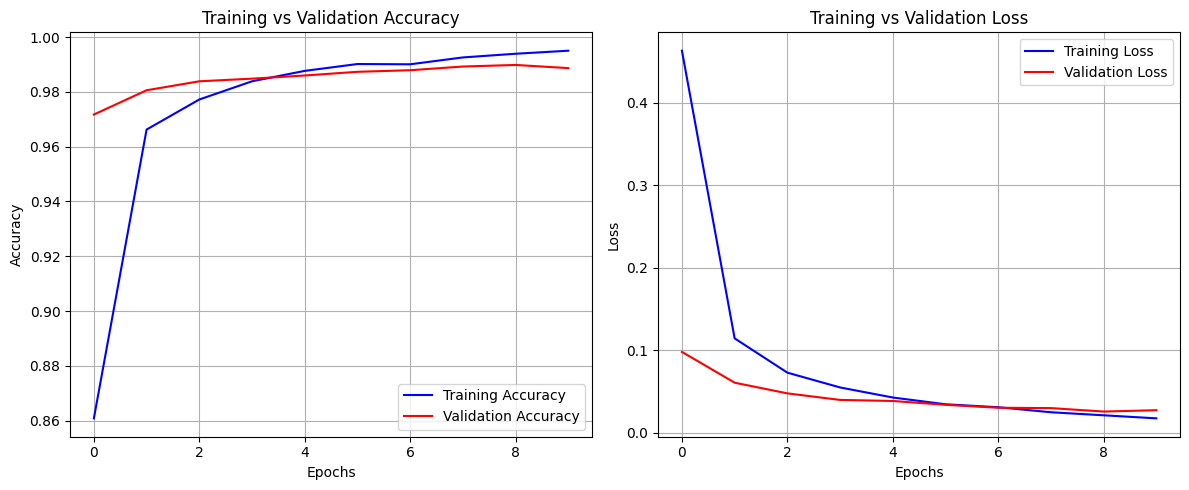

In [5]:
# Create accuracy and loss plots
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], 'b-', label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], 'b-', label='Training Loss')
plt.plot(history_dict['val_loss'], 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Some other metric for model evaluation


In [6]:
# Generate predictions
y_pred = []
y_true = []

for images, labels in valid_dataset:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Calculate precision, recall, and f1-score
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Model Evaluation Metrics:")
print("=" * 30)
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print("=" * 30)

2025-10-06 23:09:22.449804: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Model Evaluation Metrics:
Precision (weighted): 0.9828
Recall (weighted): 0.9817
F1-Score (weighted): 0.9816


### Confusion Matrix


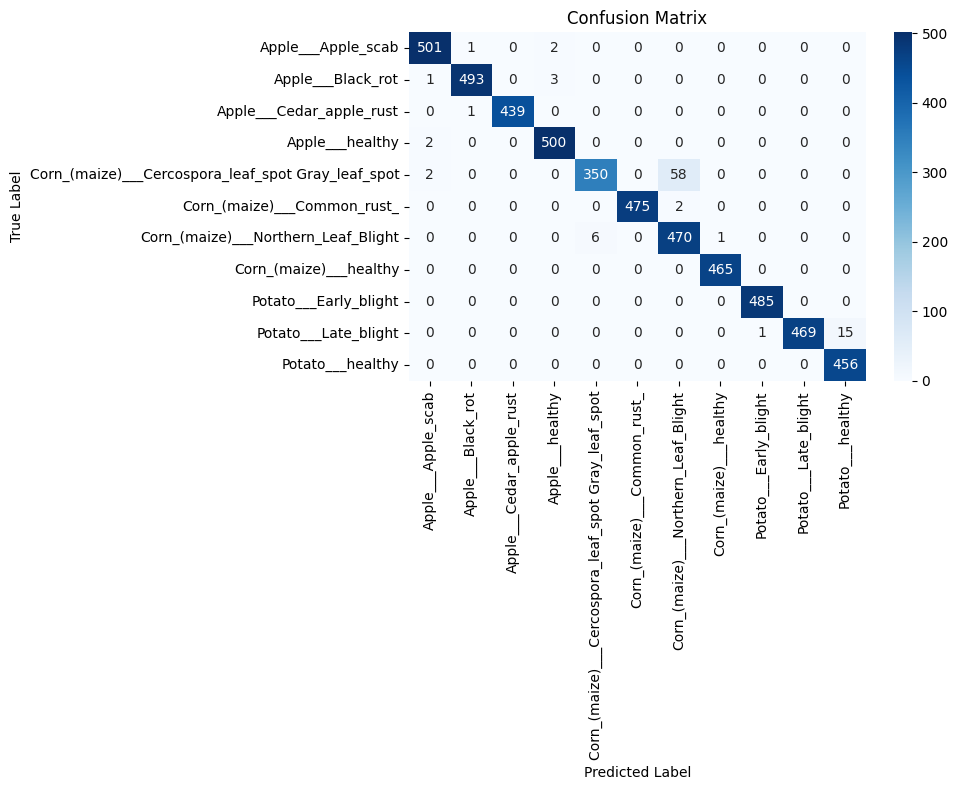

In [7]:

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Classification Report


In [8]:
# Print detailed classification report
print("Classification Report:")
print("=" * 120)
report = classification_report(y_true, y_pred, 
                             target_names=class_names, 
                             digits=4)
print(report)
print("=" * 120)

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9901    0.9940    0.9921       504
                                 Apple___Black_rot     0.9960    0.9920    0.9940       497
                          Apple___Cedar_apple_rust     1.0000    0.9977    0.9989       440
                                   Apple___healthy     0.9901    0.9960    0.9930       502
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9831    0.8537    0.9138       410
                       Corn_(maize)___Common_rust_     1.0000    0.9958    0.9979       477
               Corn_(maize)___Northern_Leaf_Blight     0.8868    0.9853    0.9335       477
                            Corn_(maize)___healthy     0.9979    1.0000    0.9989       465
                             Potato___Early_blight     0.9979    1.0000    0.9990       485
                              Potato___Late_blight     1